In [1]:
!pip install faker plotly scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random
from faker import Faker

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
fake = Faker()

loan_statuses = ['Fully Paid', 'Default']
home_ownerships = ['Rent', 'Own', 'Mortgage']
purposes = ['Education', 'Business', 'Car', 'Medical', 'Personal']
grades = ['A', 'B', 'C', 'D']

data = []

for i in range(1000):

    annual_inc = random.randint(20000, 150000)
    loan_amnt = random.randint(1000, 50000)
    int_rate = round(random.uniform(5, 25), 2)

    term = random.choice([36, 60])

    emp_length = random.randint(1, 20)

    home = random.choice(home_ownerships)
    purpose = random.choice(purposes)
    grade = random.choice(grades)

    status = random.choice(loan_statuses)

    data.append([
        loan_amnt,
        term,
        int_rate,
        annual_inc,
        emp_length,
        home,
        purpose,
        grade,
        status
    ])

df = pd.DataFrame(data, columns=[
    'loan_amnt',
    'term',
    'int_rate',
    'annual_inc',
    'emp_length',
    'home_ownership',
    'purpose',
    'grade',
    'loan_status'
])

df.head()

,loan_amnt,term,int_rate,annual_inc,emp_length,home_ownership,purpose,grade,loan_status
0,7195,36,12.47,67247,8,Own,Personal,C,Default
1,17980,36,10.56,116790,20,Own,Business,B,Fully Paid
2,27732,60,20.68,83458,4,Own,Car,A,Fully Paid
3,21633,36,24.71,55544,2,Rent,Personal,C,Fully Paid
4,14458,36,22.00,53467,13,Mortgage,Medical,C,Default


In [4]:
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df.info()

loan_amnt         0
term              0
int_rate          0
annual_inc        0
emp_length        0
home_ownership    0
purpose           0
grade             0
loan_status       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   loan_amnt       1000 non-null   int64  
 1   term            1000 non-null   int64  
 2   int_rate        1000 non-null   float64
 3   annual_inc      1000 non-null   int64  
 4   emp_length      1000 non-null   int64  
 5   home_ownership  1000 non-null   object 
 6   purpose         1000 non-null   object 
 7   grade           1000 non-null   object 
 8   loan_status     1000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 70.4+ KB


Average Loan Amount: 26017.55
Average Income: 85672.256


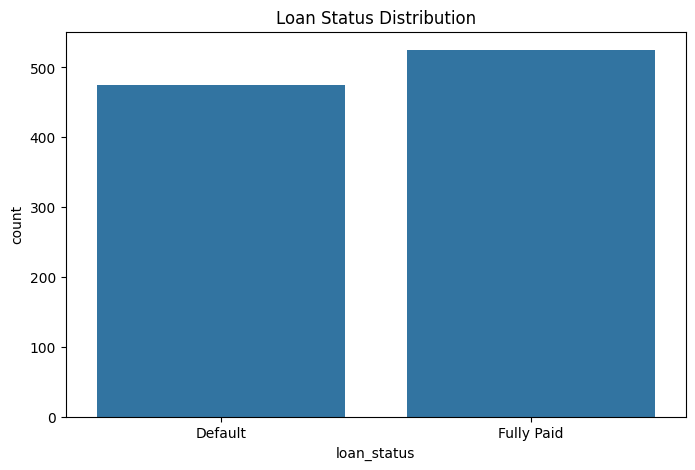

Maximum Loan: 49982
Minimum Loan: 1023


In [6]:
print("Average Loan Amount:", df['loan_amnt'].mean())

print("Average Income:", df['annual_inc'].mean())
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='loan_status'
)

plt.title("Loan Status Distribution")
plt.show()
print("Maximum Loan:", df['loan_amnt'].max())

print("Minimum Loan:", df['loan_amnt'].min())

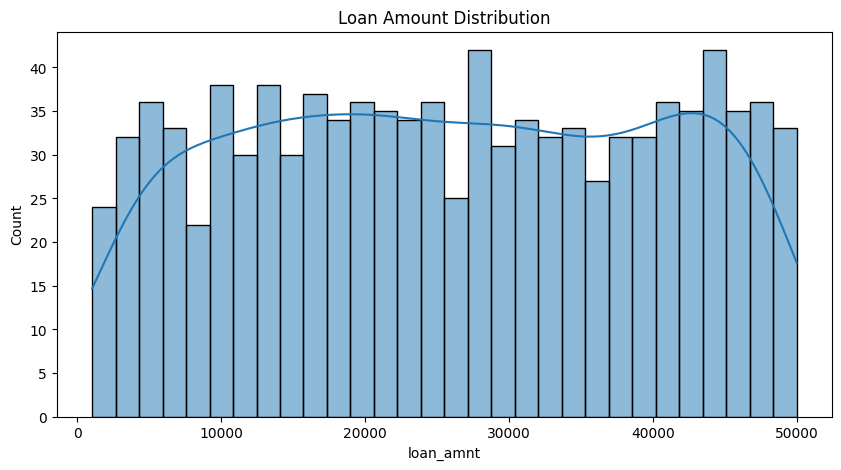

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['loan_amnt'],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.show()

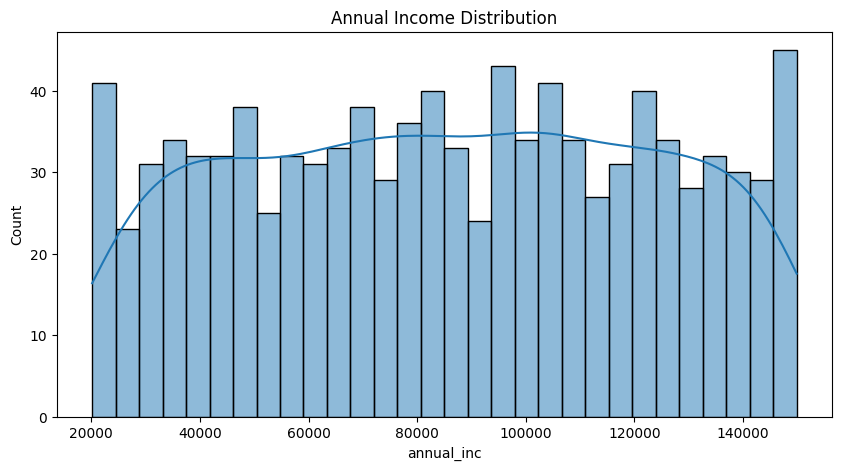

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['annual_inc'],
    bins=30,
    kde=True
)

plt.title("Annual Income Distribution")
plt.show()

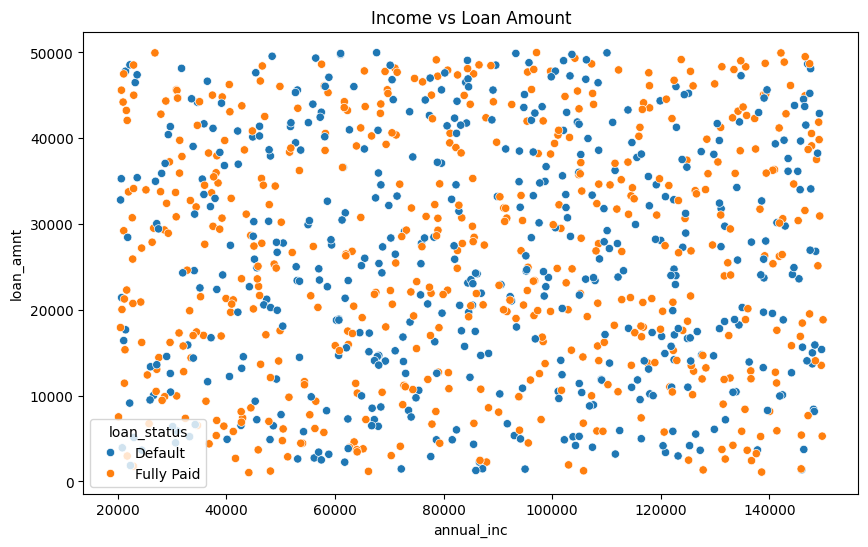

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='annual_inc',
    y='loan_amnt',
    hue='loan_status'
)

plt.title("Income vs Loan Amount")
plt.show()

In [10]:
fig = px.bar(
    df,
    x='purpose',
    color='loan_status',
    title='Loan Purpose Analysis'
)

fig.show()

In [11]:
fig = px.bar(
    df,
    x='home_ownership',
    color='loan_status',
    title='Home Ownership vs Loan Status'
)

fig.show()

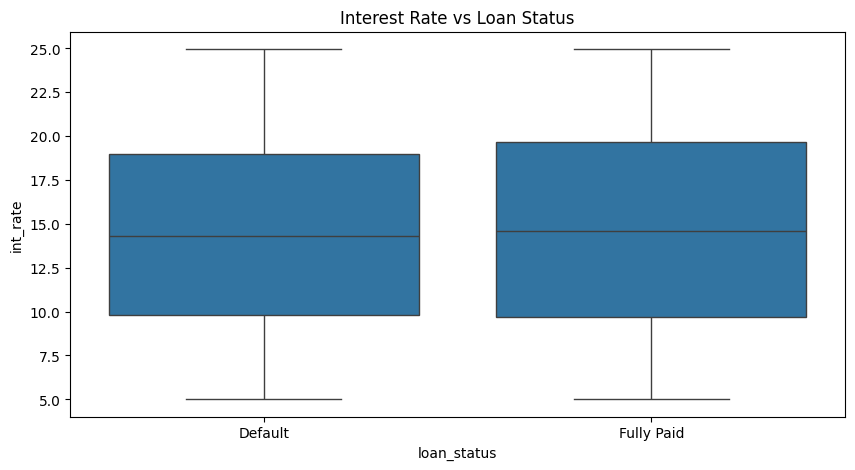

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='int_rate'
)

plt.title("Interest Rate vs Loan Status")
plt.show()

In [13]:
def risk_level(rate):

    if rate < 10:
        return "Low Risk"

    elif rate < 18:
        return "Medium Risk"

    else:
        return "High Risk"

df['Risk_Level'] = df['int_rate'].apply(risk_level)

df[['int_rate','Risk_Level']].head()

,int_rate,Risk_Level
0,12.47,Medium Risk
1,10.56,Medium Risk
2,20.68,High Risk
3,24.71,High Risk
4,22.00,High Risk


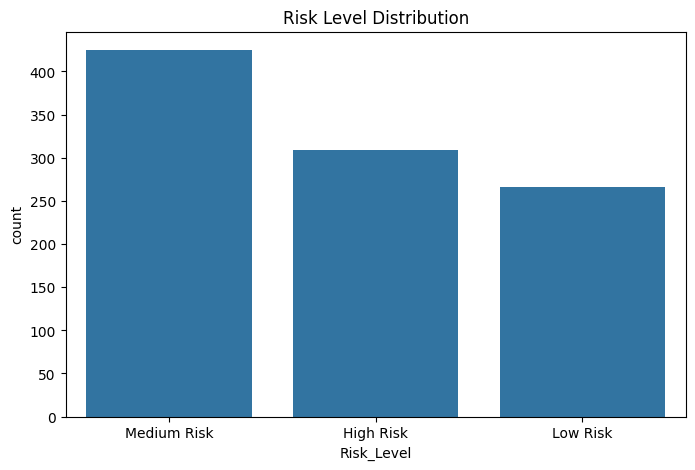

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Risk_Level'
)

plt.title("Risk Level Distribution")
plt.show()

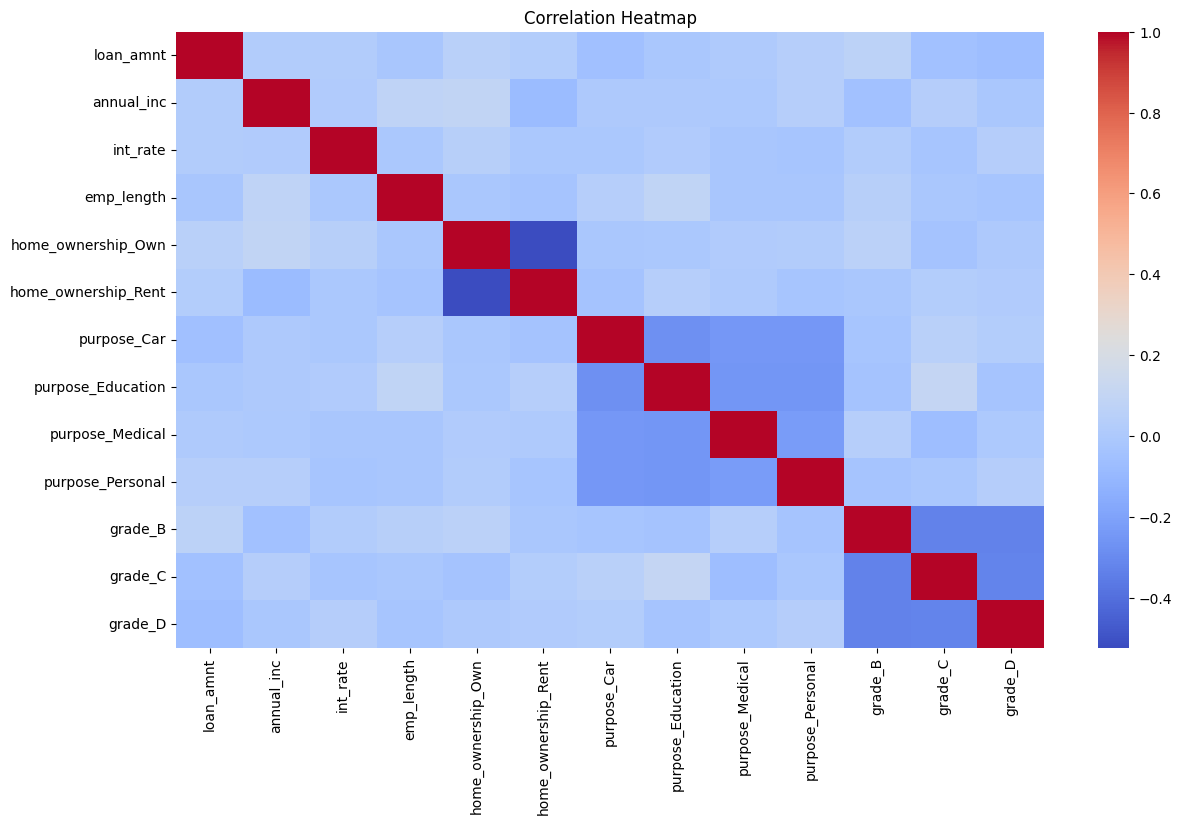

In [15]:
encoded = pd.get_dummies(
    df[['home_ownership','purpose','grade']],
    drop_first=True
)

corr_df = pd.concat([
    df[['loan_amnt','annual_inc','int_rate','emp_length']],
    encoded
], axis=1)

plt.figure(figsize=(14,8))

sns.heatmap(
    corr_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
X = df[['annual_inc','int_rate','term']]

y = df['loan_amnt']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [17]:
predictions = model.predict(X_test)

print(predictions[:10])

[25583.67345351 26283.9969123  25294.89490338 25513.45097968
 25691.1435407  25872.74782719 26182.16492748 25029.97253692
 25825.17726485 26098.93063042]


In [18]:
score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: -0.00992881778407595


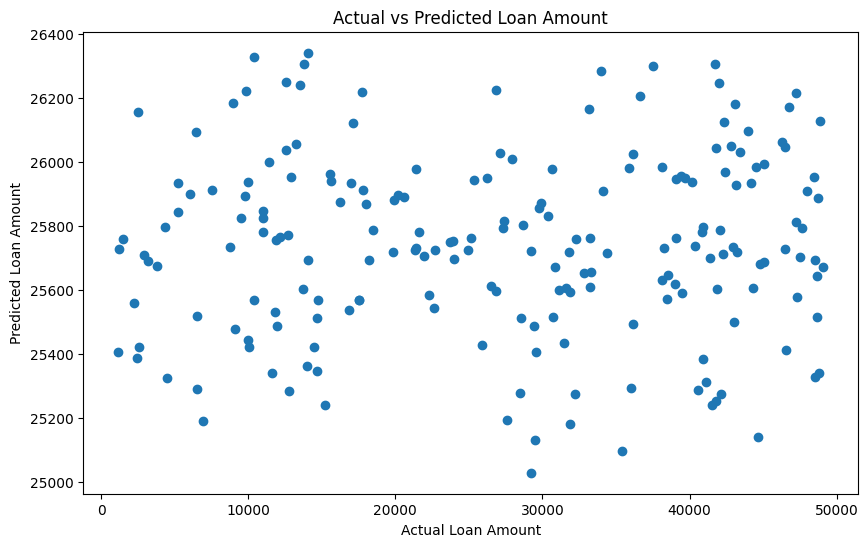

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")

plt.title("Actual vs Predicted Loan Amount")

plt.show()

In [20]:
print("Total Records:", len(df))

print("Average Income:",
      round(df['annual_inc'].mean(),2))

print("Average Loan Amount:",
      round(df['loan_amnt'].mean(),2))

print("Average Interest Rate:",
      round(df['int_rate'].mean(),2))

print("Model R2 Score:",
      round(score,4))

Total Records: 1000
Average Income: 85672.26
Average Loan Amount: 26017.55
Average Interest Rate: 14.65
Model R2 Score: -0.0099
